In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import permutation_importance

# Fixed seed for reproducible results
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
sns.set_palette('colorblind')

In [3]:
# Load the dataset
df = pd.read_csv('../dataset/regression_insurance.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1750, 7)


,age,sex,bmi,children,smoker,region,charges
0,56,female,27.44,1,no,northeast,19353.34
1,46,female,37.97,0,no,northwest,16773.90
2,32,female,17.16,3,no,northwest,12738.93
3,60,female,24.27,0,yes,southeast,45168.58
4,25,female,29.82,0,no,northeast,10892.71


In [4]:
# Dataset inspection
print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
df.describe()

Rows: 1750  Columns: 7

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


,age,bmi,children,charges
count,1750.000000,1732.000000,1750.000000,1732.000000
mean,41.333143,30.799677,1.095429,22609.173014
std,13.488508,6.151967,1.204875,16687.754532
min,18.000000,15.000000,0.000000,5477.710000
25%,30.000000,26.647500,0.000000,13298.680000
50%,42.000000,30.955000,1.000000,17002.200000
75%,53.000000,34.900000,2.000000,21577.707500
max,64.000000,50.490000,5.000000,93858.930000


In [5]:
# Check missing values and duplicate records
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
age          0
sex          0
bmi         18
children     0
smoker       0
region       0
charges     18
dtype: int64

Duplicate rows: 0


In [6]:
# Target variable (charges) distribution summary
print(df['charges'].describe())
print("\nSkewness of charges:", round(df['charges'].skew(), 3))

count     1732.000000
mean     22609.173014
std      16687.754532
min       5477.710000
25%      13298.680000
50%      17002.200000
75%      21577.707500
max      93858.930000
Name: charges, dtype: float64

Skewness of charges: 2.182


In [7]:
# Handle missing values and duplicate records
# Rows with a missing target cannot be used for supervised learning, so they are dropped
df = df.dropna(subset=['charges']).reset_index(drop=True)

# BMI is numeric and right-tailed, so the median is used for imputation
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())

Shape after cleaning: (1732, 7)
Remaining missing values: 0
Remaining duplicate rows: 0


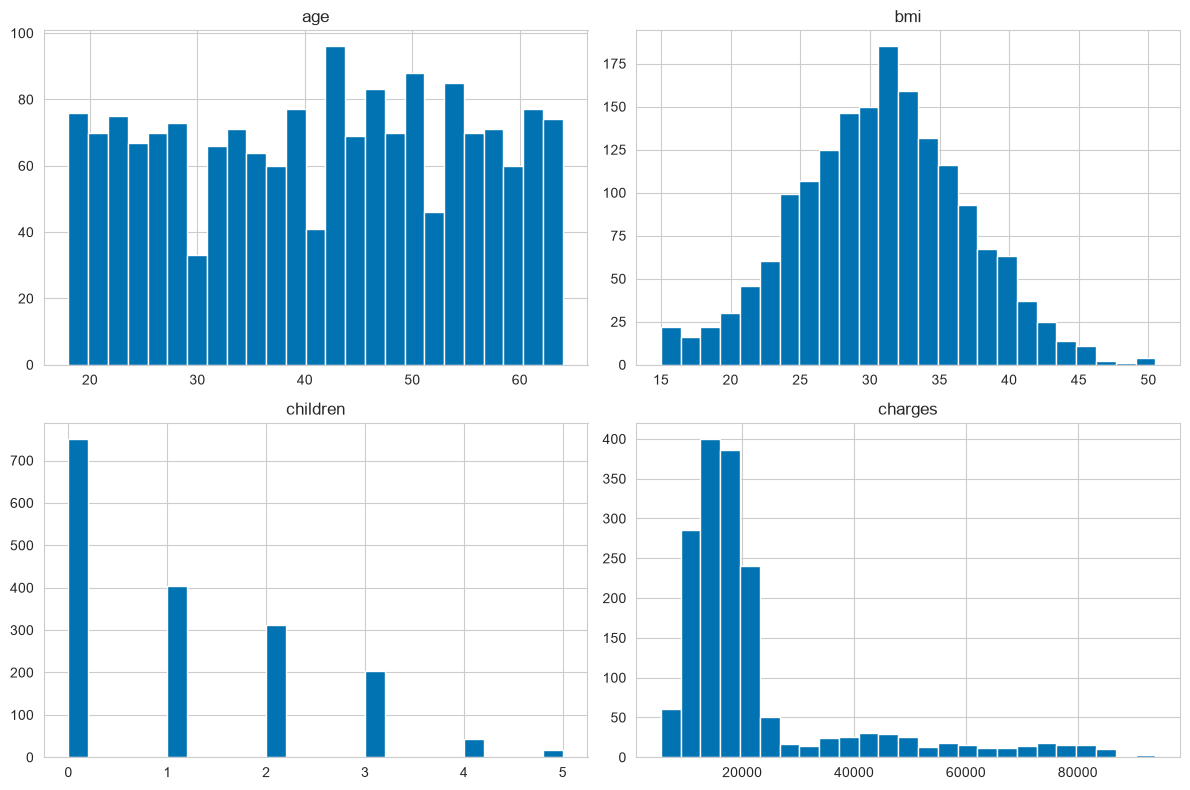

In [8]:
# Distribution of numerical features
df[['age', 'bmi', 'children', 'charges']].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

### Insight
`age` is spread fairly evenly across the 18-64 range and `bmi` is roughly symmetric around 31,
so neither needs a transformation. `children` is concentrated at 0-2, and `charges` is clearly
right-skewed with a long upper tail, which is why RMSE will stay large relative to MAE.

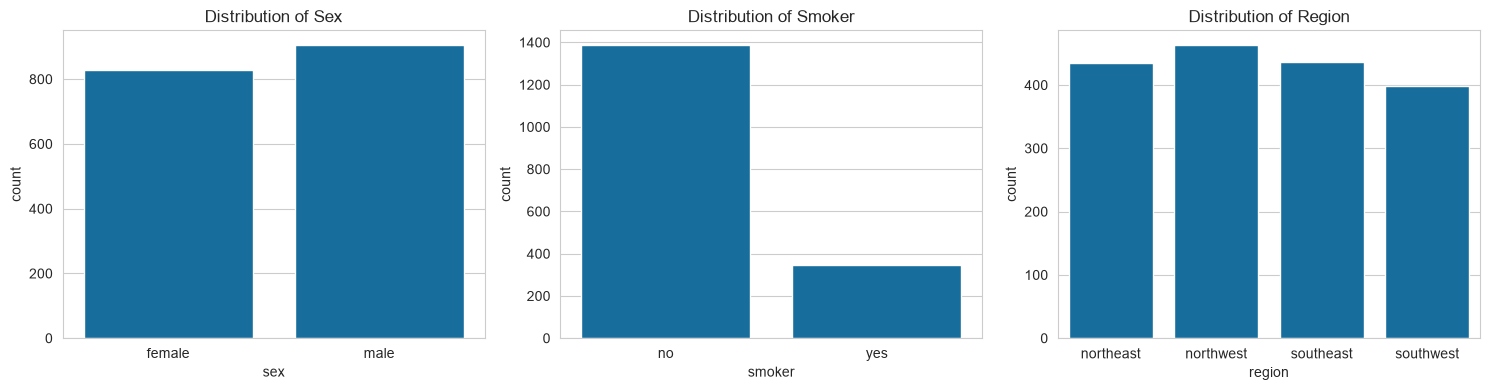

        female   male      no  northeast  northwest  southeast  southwest  \
sex      827.0  905.0     NaN        NaN        NaN        NaN        NaN   
smoker     NaN    NaN  1387.0        NaN        NaN        NaN        NaN   
region     NaN    NaN     NaN      434.0      463.0      437.0      398.0   

          yes  
sex       NaN  
smoker  345.0  
region    NaN  


In [9]:
# Distribution of categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='sex', ax=axes[0])
axes[0].set_title('Distribution of Sex')
sns.countplot(data=df, x='smoker', ax=axes[1])
axes[1].set_title('Distribution of Smoker')
sns.countplot(data=df, x='region', ax=axes[2])
axes[2].set_title('Distribution of Region')
plt.tight_layout()
plt.show()

print(df[['sex', 'smoker', 'region']].apply(lambda c: c.value_counts()).T)

### Insight
`sex` and `region` are close to balanced, so neither is likely to bias the model. `smoker` is
imbalanced — only about one record in five is a smoker — yet this is the variable with the
largest effect on charges, so the minority group carries most of the high-cost cases.

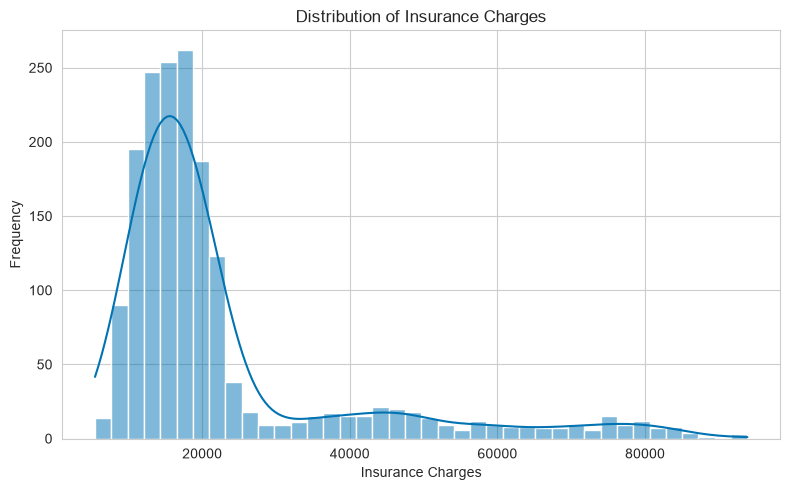

In [10]:
# Target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, bins=40)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Insurance Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Insight
The target is right-skewed (skewness of about 2.2). Half the customers are billed under
roughly 17,000 while a small group runs past 60,000. A model that predicts the bulk of the
distribution well can still produce large errors on this tail.

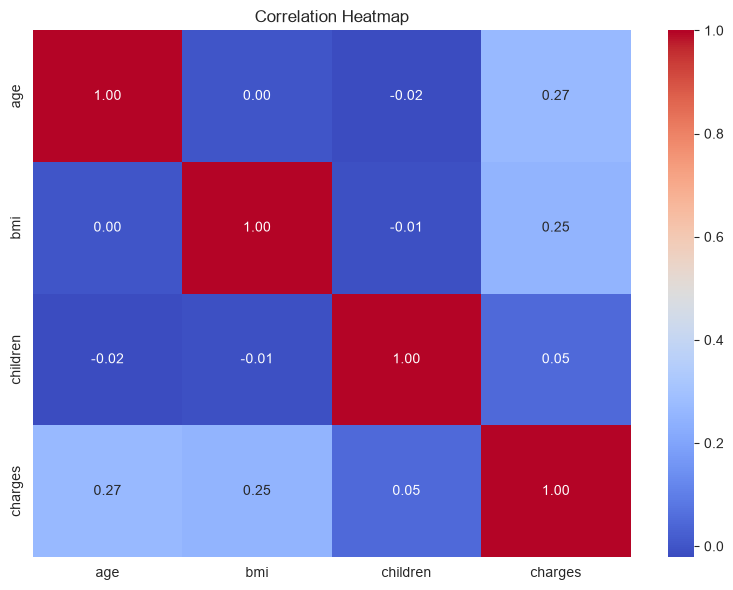

In [11]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Insight
No numeric feature is strongly correlated with `charges` on its own — `age` is about 0.27,
`bmi` about 0.25 and `children` close to zero. The weak linear correlations suggest the
strongest signal is categorical (`smoker`) and that non-linear models may fit better than a
plain linear one.

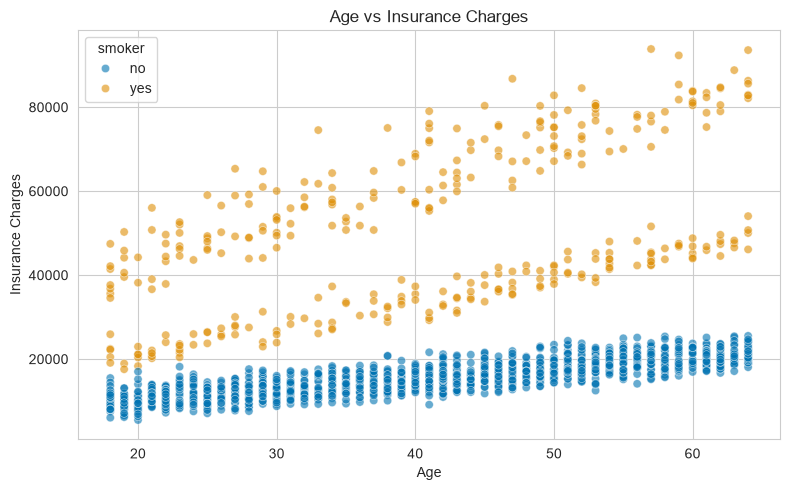

In [12]:
# Age vs charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.tight_layout()
plt.show()

### Insight
Charges rise with age, but the points split into two separate bands by smoking status.
Within non-smokers the relationship with age is strong and nearly linear; smokers sit on a much
higher, more scattered band. This split explains why the overall age correlation looked weak.

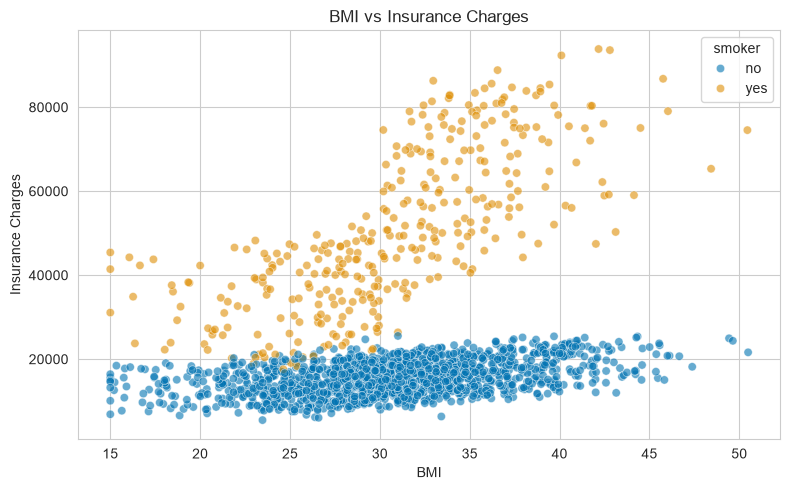

Correlation of BMI with charges, by smoker status:
smoker
no     0.439
yes    0.722
dtype: float64


In [13]:
# BMI vs charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.tight_layout()
plt.show()

print("Correlation of BMI with charges, by smoker status:")
print(df.groupby('smoker').apply(lambda g: g['bmi'].corr(g['charges']), include_groups=False).round(3))

### Insight
BMI barely moves charges for non-smokers, but among smokers the two climb together strongly
(correlation of about 0.72 versus 0.44). BMI therefore matters mainly in combination with
smoking, which is an interaction a tree-based model can pick up automatically.

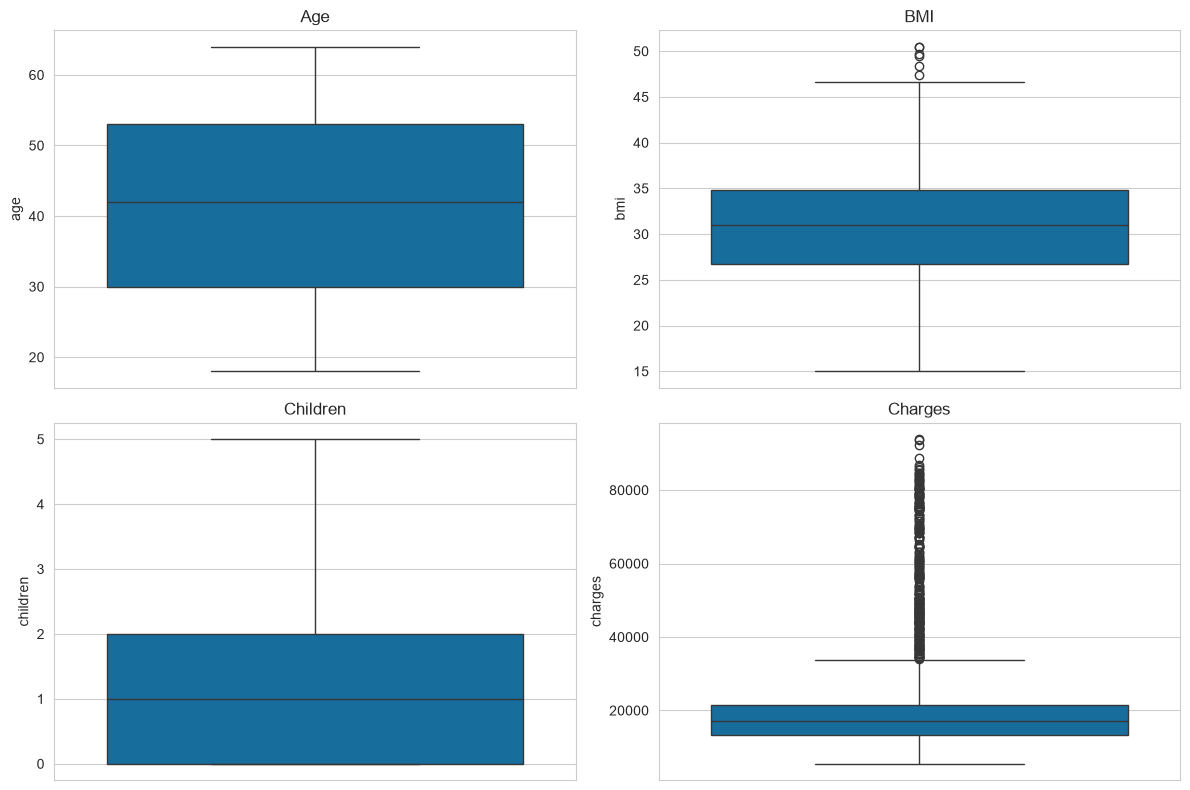

age : 0 outliers
bmi : 6 outliers
children : 0 outliers
charges : 276 outliers


In [14]:
# Outlier detection using box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(y=df['age'], ax=axes[0, 0]); axes[0, 0].set_title('Age')
sns.boxplot(y=df['bmi'], ax=axes[0, 1]); axes[0, 1].set_title('BMI')
sns.boxplot(y=df['children'], ax=axes[1, 0]); axes[1, 0].set_title('Children')
sns.boxplot(y=df['charges'], ax=axes[1, 1]); axes[1, 1].set_title('Charges')
plt.tight_layout()
plt.show()

# Count outliers using the IQR rule
for column in ['age', 'bmi', 'children', 'charges']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    print(column, ":", len(outliers), "outliers")

### Insight
`age` and `children` contain no IQR outliers and `bmi` only a handful. `charges` flags a few
hundred high values, but these are real high-cost customers (mostly smokers) rather than data
errors, so the target is left untouched and only the input features are capped.

In [15]:
# Outlier treatment using IQR capping on input features
for col in ['age', 'bmi', 'children']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("Ranges after IQR capping:")
print(df[['age', 'bmi', 'children']].agg(['min', 'max']))

Ranges after IQR capping:
     age    bmi  children
min   18  15.00         0
max   64  47.09         5


In [16]:
# Feature engineering
df['bmi_age'] = df['bmi'] * df['age']

print("Correlation with charges:")
print(df[['age', 'bmi', 'bmi_age', 'charges']].corr()['charges'].round(3))
df.head()

Correlation with charges:
age        0.270
bmi        0.248
bmi_age    0.354
charges    1.000
Name: charges, dtype: float64


,age,sex,bmi,children,smoker,region,charges,bmi_age
0,56,female,27.44,1,no,northeast,19353.34,1536.64
1,46,female,37.97,0,no,northwest,16773.90,1746.62
2,32,female,17.16,3,no,northwest,12738.93,549.12
3,60,female,24.27,0,yes,southeast,45168.58,1456.20
4,25,female,29.82,0,no,northeast,10892.71,745.50


### Insight
`bmi_age` multiplies BMI by age so that a single column carries their joint effect. Medical
cost tends to rise when a high BMI is combined with higher age rather than from either alone,
and the combined feature correlates more strongly with `charges` (about 0.35) than `age` (0.27)
or `bmi` (0.25) does on its own, so it gives the model a more direct signal to split on.

In [17]:
# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

print("Features:", X.columns.tolist())
print("Target  : charges")

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_age']
Target  : charges


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1385, 7)
Testing set : (347, 7)


In [19]:
# One-hot encoding of categorical variables
X_train_encoded = pd.get_dummies(X_train, columns=['sex', 'smoker', 'region'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['sex', 'smoker', 'region'], drop_first=True)

# Keep the same columns in both sets
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (1385, 9)
Encoded testing shape : (347, 9)


In [20]:
# Feature scaling (scaler fitted on the training set only to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns, index=X_train_encoded.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns, index=X_test_encoded.index
)

print("Training data standardized.")
print("Testing data standardized.")

Training data standardized.
Testing data standardized.


In [21]:
# Effect of feature scaling on KNN
knn_unscaled = KNeighborsRegressor()
knn_unscaled.fit(X_train_encoded, y_train)
r2_unscaled = r2_score(y_test, knn_unscaled.predict(X_test_encoded))

knn_scaled = KNeighborsRegressor()
knn_scaled.fit(X_train_scaled, y_train)
r2_scaled = r2_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"Default KNN (k=5) R2 on unscaled features: {r2_unscaled:.4f}")
print(f"Default KNN (k=5) R2 on scaled features  : {r2_scaled:.4f}")

Default KNN (k=5) R2 on unscaled features: 0.0571
Default KNN (k=5) R2 on scaled features  : 0.9475


### Insight
Scaling changes the result sharply because KNN uses Euclidean distance, and the unscaled
`bmi_age` column (values in the hundreds) otherwise dominates every distance calculation.
The scaled features are used for the baseline and tuned models below.

In [22]:
# Train baseline model
knn_baseline = KNeighborsRegressor()
knn_baseline.fit(X_train_scaled, y_train)
y_pred_base = knn_baseline.predict(X_test_scaled)
print("Baseline model trained successfully.")

Baseline model trained successfully.


In [23]:
# Evaluate baseline model
baseline_r2 = r2_score(y_test, y_pred_base)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
baseline_mae = mean_absolute_error(y_test, y_pred_base)

print("Baseline R2  :", round(baseline_r2, 4))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline MAE :", round(baseline_mae, 2))

Baseline R2  : 0.9475
Baseline RMSE: 4027.11
Baseline MAE : 2399.73


In [24]:
# Hyperparameter tuning
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # 1 = Manhattan distance, 2 = Euclidean distance
}

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

# Best hyperparameters
print("Best params:", grid_search.best_params_)
print("Best CV R2 :", round(grid_search.best_score_, 4))

Best params: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best CV R2 : 0.949


In [25]:
# Train improved model
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
print("Improved model trained with the best hyperparameters.")

Improved model trained with the best hyperparameters.


In [26]:
# Evaluate improved model
tuned_r2 = r2_score(y_test, y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
tuned_mae = mean_absolute_error(y_test, y_pred)

r2, rmse, mae = tuned_r2, tuned_rmse, tuned_mae

print("Tuned R2  :", round(tuned_r2, 4))
print("Tuned RMSE:", round(tuned_rmse, 2))
print("Tuned MAE :", round(tuned_mae, 2))

Tuned R2  : 0.9413
Tuned RMSE: 4258.38
Tuned MAE : 2310.97


In [27]:
# Baseline vs improved model comparison
comparison = pd.DataFrame({
    'Model': ['K-Nearest Neighbors Regressor (baseline)', 'K-Nearest Neighbors Regressor (tuned)'],
    'R2': [baseline_r2, tuned_r2],
    'RMSE': [baseline_rmse, tuned_rmse],
    'MAE': [baseline_mae, tuned_mae]
})
display(comparison.round(4))

print("R2 Improvement  :", round(tuned_r2 - baseline_r2, 4))
print("RMSE Improvement:", round(baseline_rmse - tuned_rmse, 2))
print("MAE Improvement :", round(baseline_mae - tuned_mae, 2))

,Model,R2,RMSE,MAE
0,K-Nearest Neighbors Regressor (baseline),0.9475,4027.1089,2399.7292
1,K-Nearest Neighbors Regressor (tuned),0.9413,4258.3776,2310.9707


R2 Improvement  : -0.0062
RMSE Improvement: -231.27
MAE Improvement : 88.76


In [28]:
# Cross-validation check on the improved model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='r2')
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print("Mean CV R2         :", round(cv_scores.mean(), 4))
print("Std  CV R2         :", round(cv_scores.std(), 4))

5-fold CV R2 scores: [0.9459 0.9525 0.9398 0.945  0.9617]
Mean CV R2         : 0.949
Std  CV R2         : 0.0075


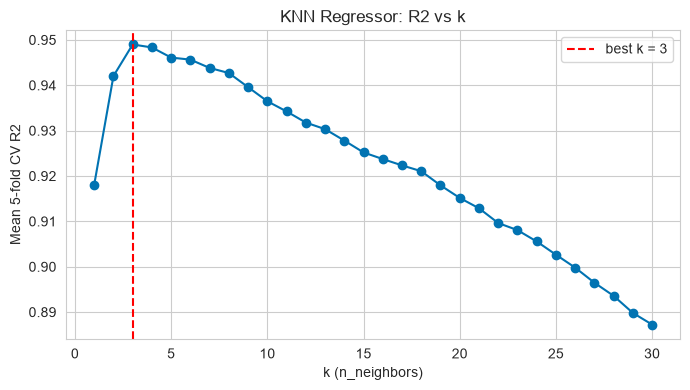

In [29]:
# R2 across different values of k
k_values = list(range(1, 31))
cv_r2_by_k = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k,
                                weights=grid_search.best_params_['weights'],
                                p=grid_search.best_params_['p'])
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_r2_by_k.append(scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(k_values, cv_r2_by_k, marker='o')
plt.axvline(grid_search.best_params_['n_neighbors'], color='r', linestyle='--',
            label=f"best k = {grid_search.best_params_['n_neighbors']}")
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean 5-fold CV R2')
plt.title('KNN Regressor: R2 vs k')
plt.legend()
plt.tight_layout()
plt.show()

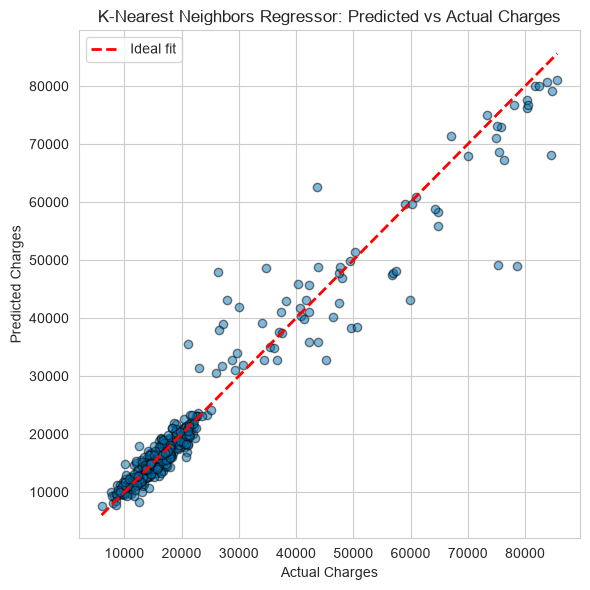

In [30]:
# Predicted vs actual plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideal fit')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('K-Nearest Neighbors Regressor: Predicted vs Actual Charges')
plt.legend()
plt.tight_layout()
plt.show()

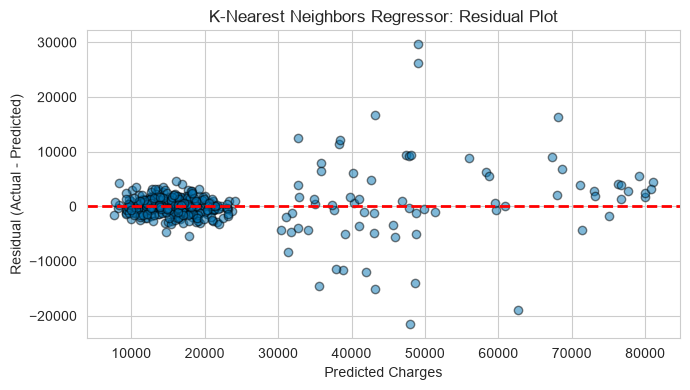

In [31]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolor='k')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Charges')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('K-Nearest Neighbors Regressor: Residual Plot')
plt.tight_layout()
plt.show()

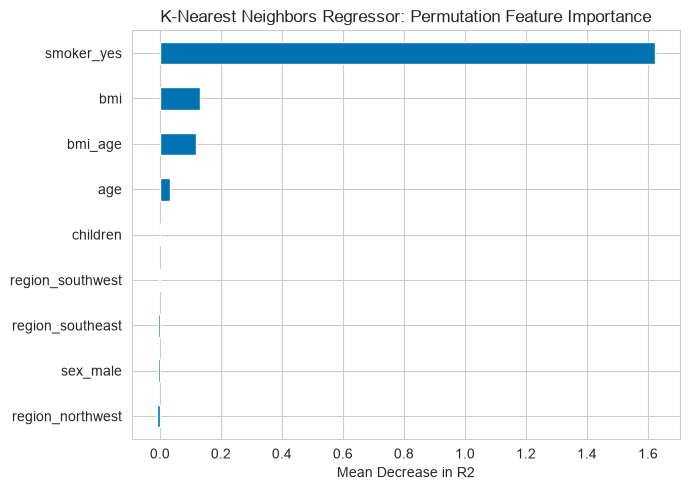

In [32]:
# Feature importance using permutation importance
perm = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='r2')
perm_importances = pd.Series(perm.importances_mean, index=X_test_scaled.columns).sort_values()

plt.figure(figsize=(7, 5))
perm_importances.plot(kind='barh')
plt.xlabel('Mean Decrease in R2')
plt.title('K-Nearest Neighbors Regressor: Permutation Feature Importance')
plt.tight_layout()
plt.show()

In [33]:
# Save results for the final 10-model comparison table
import os

os.makedirs('../results', exist_ok=True)
results_path = '../results/regression_results.csv'

row = pd.DataFrame([{'Model': 'K-Nearest Neighbors Regressor', 'R2': r2, 'RMSE': rmse, 'MAE': mae}])

if os.path.exists(results_path):
    saved = pd.read_csv(results_path)
    saved = saved[saved['Model'] != 'K-Nearest Neighbors Regressor']
    row = pd.concat([saved, row], ignore_index=True)

row.to_csv(results_path, index=False)

# Save the test-set predictions so the summary notebook can plot the best model
os.makedirs('../results/predictions', exist_ok=True)
pd.DataFrame({'y_test': y_test.values, 'y_pred': y_pred}).to_csv(
    '../results/predictions/K-Nearest Neighbors Regressor.csv', index=False
)

row.sort_values('R2', ascending=False).reset_index(drop=True)

,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.989048,1839.924387,1159.911324
1,Random Forest Regressor,0.988304,1901.395618,1229.659199
2,Decision Tree Regressor,0.984244,2206.892046,1444.269698
3,Polynomial Regression,0.964061,3333.065446,2073.471440
4,K-Nearest Neighbors Regressor,0.941337,4258.377563,2310.970655
5,ElasticNet Regression (tuned),0.839121,7051.976869,4577.759537
6,Ridge Regression (tuned),0.839106,7052.290344,4582.676408
7,Lasso Regression (tuned),0.838930,7056.162283,4532.433619
8,Linear Regression,0.838844,7058.032339,4594.205839
9,Support Vector Regressor,0.780737,8232.724229,3912.390369


In [34]:
# Load the saved results from every regression notebook
results_path = '../results/regression_results.csv'
all_results = pd.read_csv(results_path)

print("Models stored in the results file:", len(all_results))
if len(all_results) < 10:
    print("Run regression notebooks 1-9 first so that all 10 models appear below.")

Models stored in the results file: 10


In [35]:
# Final comparison table for all 10 regression models, ranked by R2
final_table = (all_results
               .sort_values('R2', ascending=False)
               .reset_index(drop=True))
final_table.index = final_table.index + 1
final_table.index.name = 'Rank'

display(final_table.round(4))

,Model,R2,RMSE,MAE
Rank,,,,
1,Gradient Boosting Regressor,0.9890,1839.9244,1159.9113
2,Random Forest Regressor,0.9883,1901.3956,1229.6592
3,Decision Tree Regressor,0.9842,2206.8920,1444.2697
4,Polynomial Regression,0.9641,3333.0654,2073.4714
5,K-Nearest Neighbors Regressor,0.9413,4258.3776,2310.9707
6,ElasticNet Regression (tuned),0.8391,7051.9769,4577.7595
7,Ridge Regression (tuned),0.8391,7052.2903,4582.6764
8,Lasso Regression (tuned),0.8389,7056.1623,4532.4336
9,Linear Regression,0.8388,7058.0323,4594.2058


### Insight
All ten models are scored on the same 20% test split, so the ranking is a fair comparison.
Gradient Boosting and Random Forest lead, followed by the single Decision Tree; Polynomial
Regression and KNN come next, and the plain linear family trails with SVR last. The gap
between the tree-based models and the linear ones matches what the EDA showed: the effect of
BMI on charges depends on smoking status, which a linear model cannot represent.

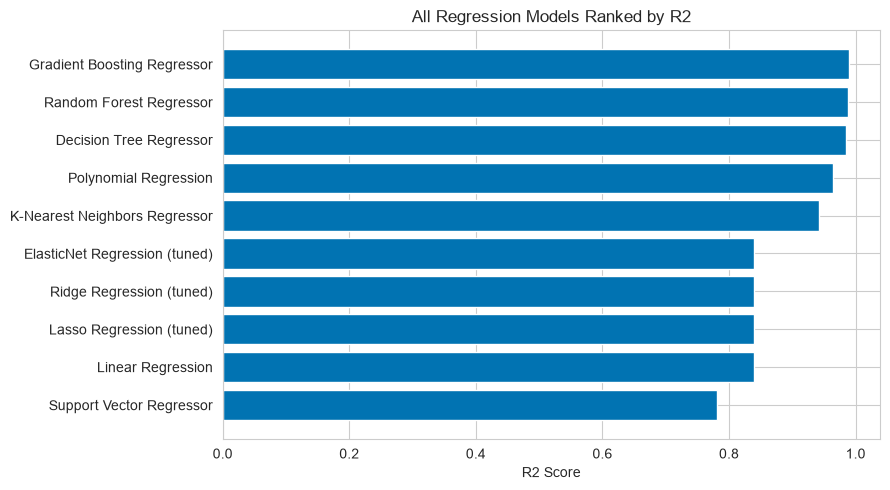

In [36]:
# Visual comparison of the ranked models
plt.figure(figsize=(9, 5))
plt.barh(final_table['Model'][::-1], final_table['R2'][::-1])
plt.xlabel('R2 Score')
plt.title('All Regression Models Ranked by R2')
plt.tight_layout()
plt.show()

Best model on the test set: Gradient Boosting Regressor


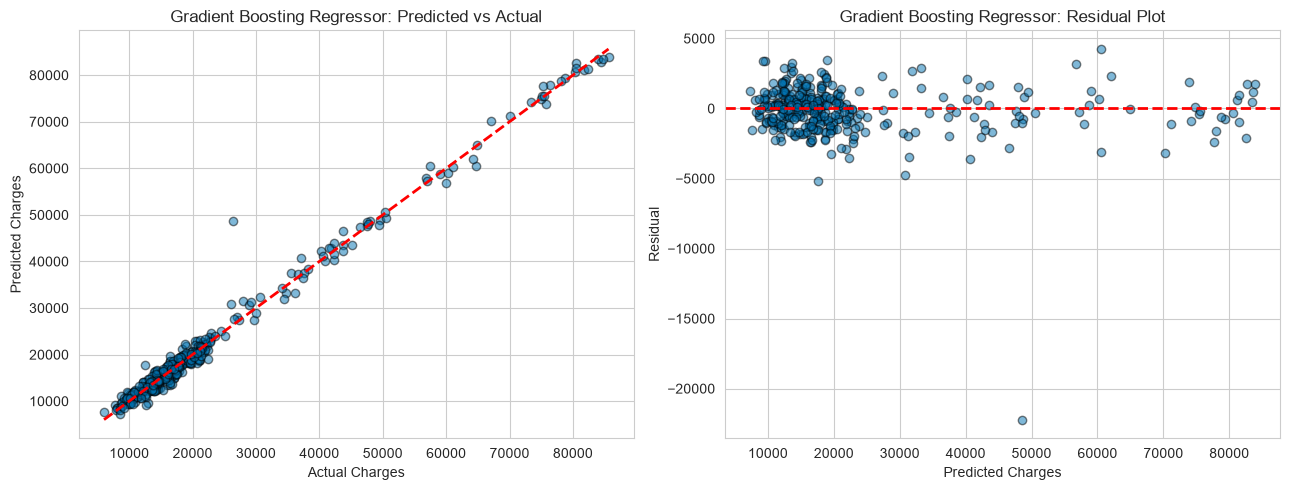

In [37]:
# Residual and predicted-vs-actual plots for the best model overall
best_name = final_table.loc[1, 'Model']
print("Best model on the test set:", best_name)

pred_file = f'../results/predictions/{best_name}.csv'
saved_preds = pd.read_csv(pred_file)
actual, bp = saved_preds['y_test'], saved_preds['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual, bp, alpha=0.5, edgecolor='k')
lims = [min(actual.min(), bp.min()), max(actual.max(), bp.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title(f'{best_name}: Predicted vs Actual')

axes[1].scatter(bp, actual - bp, alpha=0.5, edgecolor='k')
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'{best_name}: Residual Plot')

plt.tight_layout()
plt.show()